### PySpark Otomoto Demo

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023


In [1]:
import os
#os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [2]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [4]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [ ]:
df.show()

26/05/16 01:57:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [5]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [6]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [7]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [8]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [9]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [10]:
df.createOrReplaceTempView("cars")

In [11]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [12]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [13]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [14]:
# zależność ceny od przebiegu
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


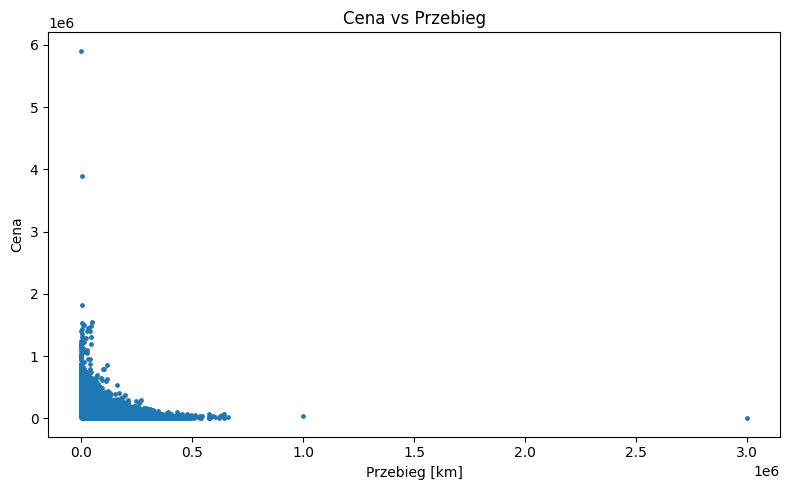

In [15]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [ ]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
# df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
# df_crimes.show(5)


### 0. Konfiguracja środowiska + importy

In [44]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (col, count, when, to_timestamp, hour, udf, broadcast)
from pyspark.sql.types import StringType
from pyspark.sql.functions import count as cnt, desc
from pyspark.sql.functions import sum as spark_sum
from pyspark.sql.functions import round as rnd

In [45]:
spark = SparkSession.builder \
    .appName("ChicagoCrimesAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.0.2


### 1. Wczytanie i Czyszczenie danych
Kroki:
- wczytanie df,
- usunięcie duplikatów,
- usunięcie `null` (wierszów z brakami w kluczowych kol),
- parsowanie dat i godziny.

In [46]:
FILE = "chicago_crimes_sample.csv"

df_crimes = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ss.SSS") \
    .csv(FILE)

print(f"Wczytano wierszy: {df_crimes.count():,}")
print(f"Kolumny: {df_crimes.columns}")
df_crimes.printSchema()

Wczytano wierszy: 149,848
Kolumny: ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']
root
 |-- id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: integer (nullable = true)
 |-- district: integer (nullable = true)
 |-- ward: integer (nullable = true)
 |-- community_area: integer (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: integer (nullable = true)
 |-- y_coordinate: integer (null

In [47]:
before = df_crimes.count()
no_dup_df = df_crimes.dropDuplicates(["id"])
after = no_dup_df.count()

print(f"Przed: {before:,}")
print(f"Po: {after:,}")
print(f"Usunięto: {before - after:,}")

Przed: 149,848
Po: 84,119
Usunięto: 65,729


In [48]:
KEY_COLS = ["date", "primary_type", "location_description", "year", "latitude", "longitude"]

clean_df = no_dup_df.dropna(subset=KEY_COLS)
print(f"Wierszy po usunięciu null: {clean_df.count():,}")

Wierszy po usunięciu null: 49,728


In [49]:
clean_df = clean_df.withColumn("date_parsed", to_timestamp(col("date"), "yyyy-MM-dd'T'HH:mm:ss.SSS"))

# Odfiltrowanie wierszy gdzie parsowanie - failed
clean_df = clean_df.filter(col("date_parsed").isNotNull())

# Lata poza zakresem
clean_df = clean_df.filter((col("year") >= 2001) & (col("year") <= 2026))

# Kolumna z godz.
clean_df = clean_df.withColumn("hour", hour(col("date_parsed")))

print(f"Wierszy po oczyszczeniu dat: {clean_df.count():,}")
clean_df.select("date", "date_parsed", "hour", "year").show(5, truncate=False)

Wierszy po oczyszczeniu dat: 49,728
+-------------------+-------------------+----+----+
|date               |date_parsed        |hour|year|
+-------------------+-------------------+----+----+
|2026-02-14 06:10:00|2026-02-14 06:10:00|6   |2026|
|2026-02-14 05:04:00|2026-02-14 05:04:00|5   |2026|
|2026-02-14 07:10:00|2026-02-14 07:10:00|7   |2026|
|2026-02-14 05:16:00|2026-02-14 05:16:00|5   |2026|
|2026-02-14 08:10:00|2026-02-14 08:10:00|8   |2026|
+-------------------+-------------------+----+----+
only showing top 5 rows


### 2. UDF i Pora Dnia

Podział:

22:00 - 6:00 -> noc

6:00 - 12:00 -> ranek

12:00 - 18:00 -> dzień

18:00 - 22:00 -> wieczór

In [50]:
def classify_time_of_day(h):
    if h is None:
        return "nieznana"
    if 0 <= h < 6:
        return "noc"
    elif 22 <= h < 24:
        return "noc"
    elif 6 <= h < 12:
        return "ranek"
    elif 12 <= h < 18:
        return "dzień"
    else:
        return "wieczór"

time_of_day_udf = udf(classify_time_of_day, StringType())

clean_df = clean_df.withColumn("time_of_day", time_of_day_udf(col("hour")))

clean_df.select("hour", "time_of_day").show(10)

+----+-----------+
|hour|time_of_day|
+----+-----------+
|   6|      ranek|
|   5|        noc|
|   7|      ranek|
|   5|        noc|
|   8|      ranek|
|   5|        noc|
|   6|      ranek|
|   7|      ranek|
|   6|      ranek|
|   9|      ranek|
+----+-----------+
only showing top 10 rows


### 3. Optymalizacja i Partycjonowanie
- cahce, bo użyjemy DF wielokrotnie
- określenie powagi przestępstwa,
- broadcast join bo severity jest mały,
- zapisanie do PARQUETA.

In [51]:
clean_df.cache()
print(f"DataFrame zbuforowany. Wierszy: {clean_df.count():,}")

DataFrame zbuforowany. Wierszy: 49,728


In [53]:
severity_data = [
    ("HOMICIDE",            "krytyczne"),
    ("CRIM SEXUAL ASSAULT", "krytyczne"),
    ("ROBBERY",             "poważne"),
    ("ASSAULT",             "poważne"),
    ("BATTERY",             "poważne"),
    ("BURGLARY",            "poważne"),
    ("MOTOR VEHICLE THEFT", "umiarkowane"),
    ("THEFT",               "umiarkowane"),
    ("CRIMINAL DAMAGE",     "umiarkowane"),
    ("DECEPTIVE PRACTICE",  "umiarkowane"),
    ("NARCOTICS",           "umiarkowane"),
    ("OTHER OFFENSE",       "inne"),
]
severity_df = spark.createDataFrame(severity_data, ["primary_type", "severity"])

# severity_df jest mały - broadcastujemy
enriched_df = clean_df.join(
    broadcast(severity_df),
    on="primary_type",
    how="left"
).fillna({"severity": "inne"})

enriched_df.select("primary_type", "severity", "time_of_day").show(10, truncate=False)

+-----------------+--------+-----------+
|primary_type     |severity|time_of_day|
+-----------------+--------+-----------+
|OTHER OFFENSE    |inne    |ranek      |
|BATTERY          |poważne |noc        |
|BATTERY          |poważne |ranek      |
|OTHER OFFENSE    |inne    |ranek      |
|ASSAULT          |poważne |ranek      |
|WEAPONS VIOLATION|inne    |ranek      |
|BURGLARY         |poważne |ranek      |
|BURGLARY         |poważne |ranek      |
|ROBBERY          |poważne |ranek      |
|ASSAULT          |poważne |ranek      |
+-----------------+--------+-----------+
only showing top 10 rows


In [54]:
PARQUET_OUT = "chicago_crimes_parquet"

enriched_df \
    .write \
    .mode("overwrite") \
    .partitionBy("year") \
    .parquet(PARQUET_OUT)

print(f"Zapisano do: {PARQUET_OUT}/  (partycje wg year)")

# check
parquet_df = spark.read.parquet(PARQUET_OUT)
print(f"Wierszy odczytanych z Parquet: {parquet_df.count():,}")

Zapisano do: chicago_crimes_parquet/  (partycje wg year)
Wierszy odczytanych z Parquet: 49,728


### 4. Analiza i Plany Zapytań -> komórki
- top 15 przestępstw,
- przestępstwo per pora dnia,


#### Top 15 przestępstw

In [55]:
crime_counts = enriched_df.groupBy("primary_type", "severity") \
    .agg(cnt("*").alias("liczba")) \
    .orderBy(desc("liczba"))

crime_counts.show(15, truncate=False)

+--------------------------+-----------+------+
|primary_type              |severity   |liczba|
+--------------------------+-----------+------+
|THEFT                     |umiarkowane|10895 |
|BATTERY                   |poważne    |9250  |
|CRIMINAL DAMAGE           |umiarkowane|5493  |
|ASSAULT                   |poważne    |4561  |
|MOTOR VEHICLE THEFT       |umiarkowane|3882  |
|OTHER OFFENSE             |inne       |3454  |
|BURGLARY                  |poważne    |3158  |
|DECEPTIVE PRACTICE        |umiarkowane|2468  |
|NARCOTICS                 |umiarkowane|1455  |
|CRIMINAL TRESPASS         |inne       |1190  |
|WEAPONS VIOLATION         |inne       |1022  |
|ROBBERY                   |poważne    |915   |
|OFFENSE INVOLVING CHILDREN|inne       |368   |
|CRIMINAL SEXUAL ASSAULT   |inne       |330   |
|SEX OFFENSE               |inne       |305   |
+--------------------------+-----------+------+
only showing top 15 rows


#### Przestępstwsa w porze dnia (posortowane malejąco)

In [56]:
by_time = enriched_df.groupBy("time_of_day") \
    .agg(cnt("*").alias("liczba")) \
    .orderBy(desc("liczba"))

by_time.show()

+-----------+------+
|time_of_day|liczba|
+-----------+------+
|      dzień| 16017|
|        noc| 13048|
|      ranek| 10632|
|    wieczór| 10031|
+-----------+------+



##### Agregacja (lokalizacja + przestępstwo + czas + ilość aresztowanych + il. domestic)

In [57]:
heavy_agg = enriched_df \
    .groupBy("primary_type", "location_description", "time_of_day") \
    .agg(
        cnt("*").alias("liczba"),
        spark_sum(col("arrest").cast("int")).alias("aresztowania"),
        spark_sum(col("domestic").cast("int")).alias("przemoc domowa")
    ) \
    .orderBy(desc("liczba"))

heavy_agg.show(20, truncate=False)

+-------------------+--------------------+-----------+------+------------+--------------+
|primary_type       |location_description|time_of_day|liczba|aresztowania|przemoc domowa|
+-------------------+--------------------+-----------+------+------------+--------------+
|MOTOR VEHICLE THEFT|STREET              |noc        |1067  |36          |15            |
|BATTERY            |APARTMENT           |noc        |1030  |254         |897           |
|CRIMINAL DAMAGE    |STREET              |noc        |873   |37          |72            |
|MOTOR VEHICLE THEFT|STREET              |wieczór    |771   |17          |6             |
|BATTERY            |APARTMENT           |dzień      |744   |138         |599           |
|THEFT              |STREET              |noc        |728   |9           |23            |
|MOTOR VEHICLE THEFT|STREET              |dzień      |626   |34          |8             |
|BATTERY            |APARTMENT           |wieczór    |625   |109         |511           |
|BATTERY  

##### Explain()

In [58]:
print("=" * 70)
print("PLAN ZAPYTANIA (heavy_agg):")
print("=" * 70)
heavy_agg.explain(extended=True)

PLAN ZAPYTANIA (heavy_agg):
== Parsed Logical Plan ==
'Sort ['liczba DESC NULLS LAST], true
+- Aggregate [primary_type#3684, location_description#3686, time_of_day#4232], [primary_type#3684, location_description#3686, time_of_day#4232, count(1) AS liczba#8259L, sum(cast(arrest#3687 as int)) AS aresztowania#8260L, sum(cast(domestic#3688 as int)) AS przemoc domowa#8261L]
   +- Project [primary_type#3684, id#3679, case_number#3680, date#3681, block#3682, iucr#3683, description#3685, location_description#3686, arrest#3687, domestic#3688, beat#3689, district#3690, ward#3691, community_area#3692, fbi_code#3693, x_coordinate#3694, y_coordinate#3695, year#3696, updated_on#3697, latitude#3698, longitude#3699, location#3700, date_parsed#3970, hour#3971, time_of_day#4232, ... 1 more fields]
      +- Project [primary_type#3684, id#3679, case_number#3680, date#3681, block#3682, iucr#3683, description#3685, location_description#3686, arrest#3687, domestic#3688, beat#3689, district#3690, ward#3691, c

## Sekcja Opcjonalna

In [59]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


In [60]:
arrest_rate = enriched_df \
    .groupBy("primary_type") \
    .agg(
        cnt("*").alias("total"),
        spark_sum(col("arrest").cast("int")).alias("areszty")
    ) \
    .withColumn(
        "wskaznik_aresztu_%",
        rnd((col("areszty") / col("total")) * 100, 1)
    ) \
    .orderBy(desc("wskaznik_aresztu_%"))

arrest_rate.show(15, truncate=False)

+---------------------------------+-----+-------+------------------+
|primary_type                     |total|areszty|wskaznik_aresztu_%|
+---------------------------------+-----+-------+------------------+
|GAMBLING                         |1    |1      |100.0             |
|LIQUOR LAW VIOLATION             |35   |34     |97.1              |
|CONCEALED CARRY LICENSE VIOLATION|40   |38     |95.0              |
|NARCOTICS                        |1455 |1354   |93.1              |
|INTERFERENCE WITH PUBLIC OFFICER |205  |181    |88.3              |
|PROSTITUTION                     |36   |30     |83.3              |
|WEAPONS VIOLATION                |1022 |754    |73.8              |
|PUBLIC INDECENCY                 |7    |5      |71.4              |
|PUBLIC PEACE VIOLATION           |256  |137    |53.5              |
|OTHER NARCOTIC VIOLATION         |2    |1      |50.0              |
|CRIMINAL TRESPASS                |1190 |411    |34.5              |
|OBSCENITY                        

In [61]:
# Top-10 typów przestępstw dla szybszego train
top10 = [r["primary_type"] for r in crime_counts.limit(10).collect()]

ml_df = enriched_df.select(
    "primary_type", "location_description",
    "hour", "district", "arrest", "domestic", "time_of_day"
).dropna().filter(col("primary_type").isin(top10))

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

Train: 36,824  |  Test: 8,982


In [62]:
label_idx = StringIndexer(inputCol="primary_type",         outputCol="label",    handleInvalid="skip")
loc_idx   = StringIndexer(inputCol="location_description", outputCol="loc_idx",  handleInvalid="skip")
time_idx  = StringIndexer(inputCol="time_of_day",          outputCol="time_idx", handleInvalid="skip")

loc_ohe  = OneHotEncoder(inputCol="loc_idx",  outputCol="loc_vec")
time_ohe = OneHotEncoder(inputCol="time_idx", outputCol="time_vec")

assembler = VectorAssembler(
    inputCols=["loc_vec", "time_vec", "hour", "district", "arrest", "domestic"],
    outputCol="features"
)

rf = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    numTrees=50, maxDepth=6, seed=42
)

pipeline = Pipeline(stages=[
    label_idx, loc_idx, time_idx,
    loc_ohe, time_ohe,
    assembler, rf
])

model = pipeline.fit(train_df)
print("Model wytrenowany")

Model wytrenowany


In [63]:
predictions = model.transform(test_df)

acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
).evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
).evaluate(predictions)

print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.3461
F1-score : 0.2228


In [64]:
spark.stop()
print("SparkSession zatrzymana.")

SparkSession zatrzymana.
